CLASS EXERCISE : BUILDING A RAG PIPLINE BASIS TREDENCE DATA

In [16]:
import requests
from bs4 import BeautifulSoup

# Send a request to the Tredence website
response = requests.get(
    url="https://www.tredence.com/",
)
# Parse the HTML content
soup = BeautifulSoup(response.content, 'html.parser')

# Attempt to find the main content
# Option 1: Try to find the HTML5 <main> tag
main_content_element = soup.find('main')

# Option 2: If <main> is not found, try to find all paragraph tags (<p>)
if not main_content_element:
    paragraphs = soup.find_all('p')
    if paragraphs:
        # Join text from all paragraphs, adding a new line between them
        extracted_text = "\n\n".join([p.get_text(separator=' ', strip=True) for p in paragraphs])
        print(extracted_text)
    else:
        print("No main content found within a <main> tag or any paragraph text.")
        print("You may need to inspect the page manually to find the specific ID or class for the content you want.")
else:
    # If <main> content is found, extract its text
    print(main_content_element.get_text(separator=' ', strip=True))

Move ideas from
                                                        experimentation to
                                                        reality with
                                                        our accelerators.

Move ideas from experimentation
                                                        to reality with
                                                        our accelerators.

Move ideas from
                                                        experimentation to
                                                        reality with
                                                        our accelerators.

Move ideas from
                                                        experimentation to
                                                        reality with
                                                        our accelerators.

Move ideas from
                                                        experimentation to
                         

In [17]:
!pip install langchain langchain-huggingface langchain-community


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [18]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=512,   # Set chunk size to 512 characters
    length_function=len
)
chunked_text = text_splitter.split_text(extracted_text)

In [19]:
chunked_text

['Move ideas from\r\n                                                        experimentation to\r\n                                                        reality with\r\n                                                        our accelerators.\n\nMove ideas from experimentation\r\n                                                        to reality with\r\n                                                        our accelerators.',
 'Move ideas from experimentation\r\n                                                        to reality with\r\n                                                        our accelerators.\n\nMove ideas from\r\n                                                        experimentation to\r\n                                                        reality with\r\n                                                        our accelerators.',
 'Move ideas from\r\n                                                        experimentation to\r\n                                 

In [20]:
from langchain_community.embeddings import SentenceTransformerEmbeddings

# Load the model for generating embeddings
embeddings = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")
# Create embeddings for the third chunk of text
chunk_embedding = embeddings.embed_documents([chunked_text[3]])

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8165.37it/s]


Step 1: store the scraped text for this single URL

In [21]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://www.tredence.com/"

response = requests.get(url)
soup = BeautifulSoup(response.content, "html.parser")

main_content_element = soup.find("main")

if main_content_element:
    extracted_text = main_content_element.get_text(separator=" ", strip=True)
else:
    paragraphs = soup.find_all("p")
    if paragraphs:
        extracted_text = "\n\n".join(
            [p.get_text(separator=" ", strip=True) for p in paragraphs]
        )
    else:
        extracted_text = ""

# Store into a small corpus DataFrame
docs_df = pd.DataFrame(
    [
        {
            "url": url,
            "text": extracted_text
        }
    ]
)

docs_df.head()

,url,text
0,https://www.tredence.com/,Move ideas from\r\n ...


In [22]:
len(docs_df.loc[0, "text"])

13737

Step 2 cell: chunk the page text into overlapping segments

In [23]:
import textwrap

# Parameters you can tune
CHUNK_SIZE = 1000    # characters per chunk
CHUNK_OVERLAP = 200  # overlapping characters between chunks

def chunk_text(text, chunk_size=CHUNK_SIZE, chunk_overlap=CHUNK_OVERLAP):
    """
    Simple character-based chunking with overlap.
    """
    if not text:
        return []
    
    chunks = []
    start = 0
    text_length = len(text)
    
    while start < text_length:
        end = start + chunk_size
        chunk = text[start:end]
        chunks.append(chunk)
        
        # Move start forward but keep some overlap
        start += chunk_size - chunk_overlap
    
    return chunks

# Apply chunking to the single row in docs_df
page_text = docs_df.loc[0, "text"]
chunks = chunk_text(page_text)

print(f"Number of chunks: {len(chunks)}")
print(f"First chunk preview:\n{chunks[0][:500]}")

Number of chunks: 18
First chunk preview:
Move ideas from
                                                        experimentation to
                                                        reality with
                                                        our accelerators.

Move ideas from experimentation
                                                        to reality with
                                                        our accelerators.

Move ideas from
                                                        experime


Step 3 cell: embeddings + Chroma storage

In [ ]:
# If not already installed in the environment, run this once:
# (You can comment this out after successful installation.)
!pip install -q chromadb openai

import os
import chromadb
from chromadb import PersistentClient
from openai import OpenAI

# Set your OpenAI API key (or rely on environment variable)
os.environ["OPENAI_API_KEY"] = ""  # replace with your key or remove if already set

# OpenAI client
client = OpenAI()

# Initialize Chroma persistent client (new-style API)
chroma_client = PersistentClient(path="./tredence_rag_db")

# Create or get a collection
collection = chroma_client.get_or_create_collection(name="tredence_website")

def embed_texts(texts):
    """
    Use OpenAI embeddings for a list of strings.
    """
    response = client.embeddings.create(
        model="text-embedding-3-small",  # choose embedding model as needed
        input=texts
    )
    return [item.embedding for item in response.data]

# Create IDs and metadata for chunks
chunk_ids = [f"tredence_chunk_{i}" for i in range(len(chunks))]
metadatas = [
    {
        "url": docs_df.loc[0, "url"],
        "chunk_index": i
    }
    for i in range(len(chunks))
]

# Compute embeddings for all chunks
chunk_embeddings = embed_texts(chunks)

# Add data to Chroma collection
collection.add(
    ids=chunk_ids,
    metadatas=metadatas,
    documents=chunks,
    embeddings=chunk_embeddings
)

print(f"Stored {len(chunks)} chunks in Chroma collection 'tredence_website'.")
print(f"Collection document count: {collection.count()}")


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Stored 18 chunks in Chroma collection 'tredence_website'.
Collection document count: 18


Step 4 cell: query Chroma and answer with OpenAI

In [29]:
TOP_K = 3  # number of chunks to retrieve

def retrieve_relevant_chunks(question, top_k=TOP_K):
    """
    Embed the question and query Chroma for the most similar chunks.
    """
    # Embed the question
    question_embedding = embed_texts([question])[0]
    
    # Query Chroma
    results = collection.query(
        query_embeddings=[question_embedding],
        n_results=top_k,
        include=["documents", "metadatas", "distances"]
    )
    
    # Chroma returns lists; flatten them into a more convenient structure
    docs = results["documents"][0]
    metadatas = results["metadatas"][0]
    distances = results["distances"][0]
    
    retrieved = []
    for doc, meta, dist in zip(docs, metadatas, distances):
        retrieved.append({
            "text": doc,
            "metadata": meta,
            "distance": dist
        })
    return retrieved

def build_context(retrieved_chunks):
    """
    Concatenate retrieved chunks into a single context string.
    """
    context_parts = []
    for i, item in enumerate(retrieved_chunks):
        context_parts.append(
            f"Chunk {i} (distance={item['distance']:.4f}):\n{item['text']}\n"
        )
    return "\n\n".join(context_parts)

def answer_question(question):
    """
    Full RAG-style pipeline: retrieve context, then ask OpenAI to answer.
    """
    retrieved = retrieve_relevant_chunks(question, top_k=TOP_K)
    
    if not retrieved:
        return "No relevant content found in the index."
    
    context = build_context(retrieved)
    
    system_prompt = (
        "You are a helpful assistant answering questions based ONLY on the "
        "provided website content. If the answer is not in the context, say "
        "you don't know and suggest the user check the website."
    )
    
    user_prompt = (
        f"Question: {question}\n\n"
        f"Context from the Tredence website:\n{context}\n\n"
        "Answer the question using only this context. "
        "Be concise but complete."
    )
    
    response = client.chat.completions.create(
        model="gpt-4o-mini",  # or another chat model
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ]
    )
    
    return response.choices[0].message.content

# Quick manual test
test_question = "What services does Tredence provide?"
print(answer_question(test_question))

Tredence provides services that focus on enabling last-mile adoption of data science to bridge the gap between insights delivery and value realization. They offer AI-powered data science solutions through their AI/ML Accelerator Ecosystem for enterprises, and they emphasize speed to action, speed to value, and speed to scale with their industry and functional expertise, as well as deep partnerships in Data & AI.


In [30]:
test_question = "What is tredence?"
print(answer_question(test_question))

Tredence is a consulting firm that focuses on bridging the gap between insights delivery and value realization by enabling the last-mile adoption of data science. They are known for their speed to action, speed to value, and speed to scale through industry expertise and partnerships in Data and AI. Tredence has received multiple awards and recognitions as a leader in various analytics and data services domains.


Step 5 cell: Gradio chatbot UI over your RAG pipeline

In [31]:
!pip install -q gradio

import gradio as gr

def rag_chatbot(message, history):
    """
    Minimal Gradio chat function.
    `message`: latest user message (string).
    `history`: previous chat turns (Gradio-managed, we don't need to modify it).
    We just return the bot reply; Gradio handles appending to history.
    """
    if not message or message.strip() == "":
        reply = "Please ask a question about the Tredence website."
    else:
        reply = answer_question(message)
    
    # Return bot's reply only; ChatInterface will update history internally.
    return reply

demo = gr.ChatInterface(
    fn=rag_chatbot,
    title="Tredence Website Q&A",
    description="Ask questions about the Tredence homepage (RAG over scraped content)."
)

demo.launch()


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


Visualization cell: UMAP + colored corpus + retrieval inspection


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


/home/parvat-khattak/.pyenv/versions/3.10.13/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


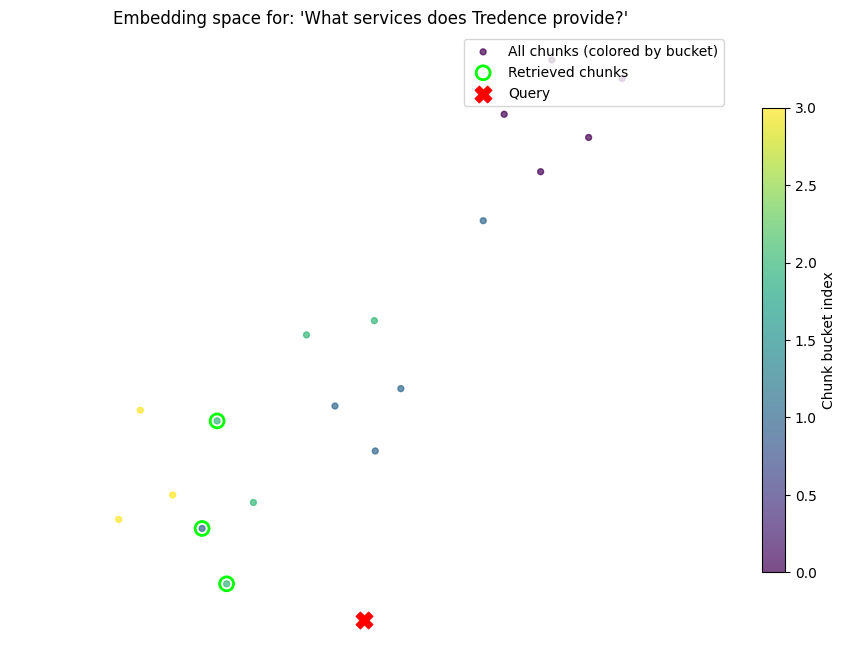


Top retrieved chunks (in order):



,id,chunk_index,text
6,tredence_chunk_6,6,"son, act, and deliver.\n\nRun Enterprise Busin..."
12,tredence_chunk_12,12,intelligence.\n\nCreate intelligent interconn...
14,tredence_chunk_14,14,artner of the Year\n\nNamed Databricks 2025 Am...


In [32]:
# INSTALL DEPENDENCIES (run once)
!pip install -q umap-learn scikit-learn

import numpy as np
import umap
import matplotlib.pyplot as plt
import pandas as pd

# 1. FETCH ALL EMBEDDINGS, METADATA, DOCUMENTS FROM CHROMA

# 'ids' are always returned; do NOT include them explicitly.
all_data = collection.get(include=["embeddings", "metadatas", "documents"])

all_embeddings = np.array(all_data["embeddings"])
all_ids = all_data["ids"]
all_metadatas = all_data["metadatas"]
all_docs = all_data["documents"]

# Build a DataFrame for inspection and coloring
corpus_df = pd.DataFrame({
    "id": all_ids,
    "embedding_idx": np.arange(len(all_ids)),
    "metadata": all_metadatas,
    "text": all_docs
})

# Extract chunk_index from metadata (if present)
def get_chunk_index(meta):
    if isinstance(meta, dict) and "chunk_index" in meta:
        return meta["chunk_index"]
    return -1  # fallback if not present

corpus_df["chunk_index"] = corpus_df["metadata"].apply(get_chunk_index)

# Bucket chunk_index for coloring (0–4, 5–9, etc.)
corpus_df["chunk_bucket"] = (corpus_df["chunk_index"] // 5).astype(int)

# 2. FIT UMAP ON FULL EMBEDDING SET

umap_transform = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=0,
    transform_seed=0
).fit(all_embeddings)

# 3. VISUALIZATION FUNCTION

def visualize_query(question, n_results=TOP_K):
    """
    Visualize where a question and its retrieved chunks lie in the embedding space.
    """
    # a) Use the same retrieval logic from your RAG pipeline
    retrieved = retrieve_relevant_chunks(question, top_k=n_results)
    
    # b) Embed query and query Chroma to get embeddings of retrieved chunks
    q_emb = embed_texts([question])[0]
    q_results = collection.query(
        query_embeddings=[q_emb],
        n_results=n_results,
        include=["embeddings"]  # <--- FIX: no 'ids' here
    )
    # ids are returned regardless of `include`
    retrieved_ids = q_results["ids"][0]
    retrieved_embeddings = np.array(q_results["embeddings"][0])
    
    # c) Project all embeddings
    projected_all = umap_transform.transform(all_embeddings)
    
    # d) Project retrieved embeddings
    projected_retrieved = umap_transform.transform(retrieved_embeddings)
    
    # e) Project query embedding
    projected_query = umap_transform.transform(np.array([q_emb]))
    
    # f) Mask for retrieved points in the corpus
    retrieved_mask = corpus_df["id"].isin(retrieved_ids).values
    
    # 4. PLOT
    plt.figure(figsize=(10, 8))
    
    # Corpus points, colored by chunk_bucket
    buckets = corpus_df["chunk_bucket"].values
    scatter = plt.scatter(
        projected_all[:, 0],
        projected_all[:, 1],
        c=buckets,
        cmap="viridis",
        s=18,
        alpha=0.7,
        label="All chunks (colored by bucket)"
    )
    
    # Retrieved chunks (outlined)
    plt.scatter(
        projected_all[retrieved_mask, 0],
        projected_all[retrieved_mask, 1],
        s=100,
        facecolors="none",
        edgecolors="lime",
        linewidths=2,
        label="Retrieved chunks"
    )
    
    # Query embedding (red X)
    plt.scatter(
        projected_query[:, 0],
        projected_query[:, 1],
        s=140,
        marker="X",
        color="red",
        label="Query"
    )
    
    plt.gca().set_aspect("equal", "datalim")
    plt.title(f"Embedding space for: '{question}'")
    plt.axis("off")
    plt.legend(loc="upper right")
    
    # Optional colorbar for bucket index
    cbar = plt.colorbar(scatter, fraction=0.03, pad=0.04)
    cbar.set_label("Chunk bucket index")
    
    plt.show()
    
    # 5. TEXT INSPECTION TABLE OF RETRIEVED CHUNKS
    retrieved_df = corpus_df[corpus_df["id"].isin(retrieved_ids)].copy()
    # Order rows according to retrieval order
    retrieved_df["order"] = retrieved_df["id"].apply(lambda x: retrieved_ids.index(x))
    retrieved_df = retrieved_df.sort_values("order")
    
    display_cols = ["id", "chunk_index", "text"]
    print("\nTop retrieved chunks (in order):\n")
    display(retrieved_df[display_cols])

# EXAMPLE USAGE
visualize_query("What services does Tredence provide?")